# Transfer Learning 기반의 CNN 모델 학습 - 완성본

---

> **📌 이 노트북의 사용 방법**
>
> 이 노트북은 셀을 하나씩 읽고 실행하며 학습할 수 있도록 재구성된 자료
> - 각 코드 셀의 **주석을 반드시 먼저 읽은 후** 실행할 것
> - `TODO` 표시가 있는 셀은 **직접 코드를 작성**하는 구간이다. 바로 위의 설명을 참고할 것
> - 각 Step이 끝날 때마다 **"관찰 포인트"**를 확인하여 결과를 스스로 해석할 것
> - 막히는 부분이 있으면, 주석에 적힌 **"왜?"** 설명을 다시 읽어보는 것을 권장한다

> **💡 이 실습의 위치: MLP → CNN → 전이학습**
>
> CNN 교안에서 이미지를 필터로 훑으며 특징을 추출하는 CNN의 원리를 학습했다.
> 그런데 CNN을 처음부터(from scratch) 학습하려면 **수십만 장의 이미지, 고성능 GPU, 며칠~몇 주의 시간**이 필요하다.
> 전이학습은 이 문제를 해결한다:
> **"이미 대규모 데이터로 학습된 CNN을 가져와서, 마지막 분류층만 교체하여 내 문제에 맞게 활용하는 방법"**
>
> ```
> MLP: "층을 쌓으면 복잡한 패턴을 학습한다"
>  → CNN: "이미지에 특화된 층 쌓기 (필터로 특징 추출)"
>  → 전이학습: "잘 쌓아둔 것을 가져다 재활용하기"
> ```

## 학습 개요

### 학습 목표
- 전이학습의 개념과 효과를 이해하고, **Linear Probing과 Fine-tuning의 차이**를 설명할 수 있다
- 사전 학습된 **ResNet-18 모델**을 불러와 CIFAR-10 데이터셋에 맞게 수정하고 학습시킬 수 있다
- **데이터 증강(Augmentation)**과 **학습률 스케줄러(Scheduler)**를 활용하여 모델 성능을 개선할 수 있다
- HuggingFace Transformers를 활용하여 **Vision Transformer(ViT)** 모델로 이미지 분류를 수행할 수 있다

### 실습 구성 (3 Step)

| Step | 내용 | 핵심 개념 | 소요 시간 |
|:---:|------|----------|:---:|
| 1 | **Linear Probing** | 특징 추출부 동결, 분류층만 학습 | 약 25분 |
| 2 | **Fine-tuning + 증강 + 스케줄러** | 전체 모델 학습, 과적합 방지, 학습률 조절 | 약 20분 |
| 3 | **ViT Inference** | HuggingFace로 최신 모델 추론 체험 | 약 15분 |


## 실습 구성

1. **학습 방향**

- **실습 구성 방식**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현

- **Required Package**
  ```
  python==3.11
  numpy>=2.0.0
  matplotlib>=3.8.0
  tqdm>=4.66.0
  torch>=2.1.0
  torchvision>=0.16.0
  datasets>=3.0.0
  transformers==4.57.1
  hf_transfer>=0.1.9
  ```
  - `ViTImageProcessor` 사용을 위해 `transformers` 버전은 `4.57.1`으로 고정합니다.

- **Step 요약**
  - **Step 1 (25분)**: Linear Probing - ResNet-18의 특징 추출 부분을 동결하고 분류층만 학습하여 전이 학습의 기본 효과 체험
  - **Step 2 (20분)**: Fine-tuning & Augmentation - 데이터 증강과 전체 모델 학습, 학습률 스케줄러를 적용하여 성능 극대화
  - **Step 3 (15분)**: Vision Transformer Inference - HuggingFace의 ViT 모델로 이미지 분류를 수행하고 결과 시각화
  - **총 소요시간(권장)**: 60분

2. **데이터셋 개요 및 저작권 정보**
  - **데이터셋 명**: CIFAR-10
  - **데이터셋 개요**: 10개 클래스(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)로 구성된 32×32 컬러 이미지 데이터셋입니다. 훈련 데이터 50,000장, 테스트 데이터 10,000장으로 구성됩니다.
  - **사용 목적**: 이미지 분류 모델 학습 및 전이 학습 효과 검증
  - **저작권/출처**: Alex Krizhevsky, Vinod Nair, Geoffrey Hinton이 공개한 데이터셋으로, 연구 및 교육 목적으로 자유롭게 사용 가능합니다.
  - **주의사항**: 본 데이터셋은 저해상도(32×32)이므로, 실무 적용 시에는 더 고해상도 데이터를 사용해야 합니다.

3. **문제 설명**
  - **문제 개요**: 이 실습은 **전이 학습(Transfer Learning)의 전체 파이프라인**을 익히기 위해 설계되었습니다. 학습자는 사전 학습된 ResNet-18 모델을 활용하여 **Linear Probing과 Fine-tuning의 차이**를 직접 체험하고, 각 단계에서 **전이학습의 효과를 정량적으로 분석**할 수 있어야 합니다.

  - **요구사항 요약**
    - **Step 1**: 사전 학습된 ResNet-18의 마지막 층만 학습(Linear Probing)하여 기본 성능 확보
    - **Step 2**: 데이터 증강과 전체 모델 Fine-tuning으로 성능 극대화
    - **Step 3**: HuggingFace ViT 모델로 추론 수행 및 결과 시각화

4. **학습 문제: Step–TODO 구체 설명**
  - **Step 1 — Linear Probing**
    - **TODO 1**: 데이터셋 준비 *(연결 학습개념: 이미지 전처리 / 정규화)* - `train_transform`과 `test_transform`을 구성하여 이미지를 (224, 224)로 리사이즈하고, 텐서로 변환하며, 전체 학습데이터의 평균/표준편차로 정규화를 진행합니다.
    - **TODO 2**: Linear Probing 설정 *(연결 학습개념: 모델 구조 이해 / 파라미터 동결)* - ResNet-18의 마지막 분류층(fc)을 CIFAR-10의 10개 클래스에 맞게 교체하고, fc층을 제외한 나머지 레이어의 가중치를 동결합니다.
    - **TODO 3**: 모델 학습 설정 *(연결 학습개념: PyTorch 학습 루프 / 최적화)* - 손실 함수(CrossEntropyLoss)와 옵티마이저(SGD, lr=0.001)를 정의하고, 학습 루프를 구현합니다(gradient 초기화 → forward pass → loss 계산 → backward pass → 파라미터 업데이트).
    - **1줄 요약**: 사전 학습 모델의 특징 추출 능력을 활용하여 최소한의 학습으로 빠르게 적응시킵니다.

  - **Step 2 — Fine-tuning & Augmentation**
    - **TODO 4**: 데이터 증강 적용 *(연결 학습개념: 데이터 증강 / 일반화 성능 향상)* - `train_transform_aug`에 RandomCrop과 RandomHorizontalFlip을 추가하여 데이터 다양성을 높입니다.
    - **TODO 5**: Fine-tuning 설정 *(연결 학습개념: Fine-tuning / 전체 모델 학습)* - 전체 레이어의 동결을 해제(`requires_grad=True`)하고, 낮은 학습률(0.0005)로 새로운 옵티마이저를 선언합니다.
    - **1줄 요약**: 데이터 증강과 전체 모델 학습으로 성능을 극대화하고 일반화 능력을 향상시킵니다.

  - **Step 3 — Vision Transformer Inference**
    - **TODO 6**: ViT 모델 로드 *(연결 학습개념: HuggingFace Transformers / 사전 학습 모델 활용)* - `ViTImageProcessor`를 사용하여 이미지 전처리기를 불러오고, `ViTForImageClassification`으로 사전 학습된 ViT 모델을 불러옵니다.
    - **1줄 요약**: Transformer 기반 최신 비전 모델을 활용하여 간편하게 이미지 분류를 수행합니다.


## Import & Install

실습에 필요한 라이브러리를 설치하고, 실험 재현성을 위해 시드를 설정한다.

> **💡 시드(Seed) 고정이란?**
>
> 딥러닝에서는 가중치 초기화, 데이터 셔플 등에 난수가 사용된다.
> 시드를 고정하면 매번 **동일한 난수 순서**가 생성되어, 코드를 다시 실행해도 **동일한 결과**를 얻을 수 있다.
> 실험 결과를 비교하거나 디버깅할 때 필수적인 설정이다.


In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "matplotlib>=3.8.0" \
    "tqdm>=4.66.0" \
    "torch>=2.1.0" \
    "torchvision>=0.16.0" \
    "datasets>=3.0.0" \
    "transformers==4.57.1" \
    "hf_transfer>=0.1.9"


In [ ]:
import random

import torch               # PyTorch 핵심: 텐서 연산 + 자동 미분
import torch.nn as nn      # 모델(레이어)을 만드는 도구 (nn.Linear, nn.Conv2d 등)
import numpy as np
import torch.optim as optim  # 옵티마이저 (SGD, Adam 등)
import torchvision           # 이미지 관련 유틸리티 (데이터셋, 사전학습 모델, 전처리)
import torchvision.transforms as transforms  # 이미지 전처리 파이프라인
from tqdm import tqdm        # 학습 진행률 표시 바

# ========== 시드 고정 ==========
# 왜 이렇게 여러 곳에 시드를 설정하는가?
# → Python 기본 random, NumPy, PyTorch(CPU), PyTorch(GPU)가
#   각각 별도의 난수 생성기를 사용하기 때문이다.
#   하나라도 빠지면 해당 부분의 결과가 매번 달라진다.
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

# CuDNN의 비결정적 알고리즘 선택을 비활성화 (결과 재현을 위해)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU가 있으면 GPU, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: mps


## Step 1: Linear Probing

### 전이학습(Transfer Learning)이란?

> **💡 핵심 질문: CNN을 처음부터 학습해야 하는가?**
>
> CNN을 처음부터(from scratch) 학습하려면 다음이 필요하다:
> - 수십만~수백만 장의 이미지 데이터
> - 고성능 GPU로 며칠~몇 주의 학습 시간
> - 학습 실패(local minimum, 과적합) 위험
>
> **전이학습**은 이 문제를 해결한다:
> "이미 대규모 데이터로 학습된 CNN을 가져와서, **마지막 분류층만 교체**하여 내 문제에 맞게 활용하는 방법"

### CNN의 구조 복습 — 특징 추출부 vs 분류부

CNN 교안에서 학습한 내용을 떠올려 보자:

```
[입력 이미지] → [특징 추출부: Conv + Pooling] → [분류부: FC Layer] → [출력]
                  ↑ 이 부분은 범용적!             ↑ 이 부분만 교체!
```

- **특징 추출부** (합성곱 + 풀링): 선, 색상, 질감, 형태 등을 감지하는 필터들이다.
  이 필터들이 학습한 **저수준 특징(엣지, 색상)은 어떤 이미지에서든 공통적으로 유용**하다.
  예를 들어 ImageNet(1000개 클래스, 100만+ 이미지)으로 학습된 "수직선 감지 필터"는
  고양이 사진에서도, 자동차 사진에서도 동일하게 사용할 수 있다.
- **분류부** (FC Layer): 추출된 특징을 보고 "이것은 고양이다/개다"를 판단하는 부분이다.
  이 부분은 **원래 학습 목적(예: ImageNet 1000개 클래스)에 맞춰져 있으므로**, 내 문제에 맞게 교체해야 한다.

### 전이학습의 두 가지 전략

| 전략 | 특징 추출부 | 분류부 | 학습 대상 | 적합한 상황 |
|------|:---:|:---:|------|------|
| **Linear Probing** | 🔒 동결 | 🔓 새로 학습 | 분류층만 (~1%) | 데이터 적음, 빠른 실험 |
| **Fine-tuning** | 🔓 동결 해제 | 🔓 학습 | 전체 모델 (100%) | 데이터 충분, 최고 성능 |

이번 Step 1에서는 **Linear Probing**을 실습한다.
Step 2에서 **Fine-tuning**으로 확장한다.

### 이번 Step에서 확인할 포인트
1. 첫 epoch부터 이미 높은 정확도가 나오는가 (Random 초기화는 ~10%, 전이학습은 ~60%+)
2. 전체 파라미터의 ~1%만 학습하는데도 70%+ 정확도를 달성하는가
3. 학습 손실이 빠르게 감소하는가


### 데이터 준비 및 전처리

학습을 위한 CIFAR-10 데이터셋을 준비한다.

> **💡 왜 224×224로 리사이즈하는가?**
>
> CIFAR-10 이미지는 원래 32×32 크기이다. 그런데 ResNet-18은 **ImageNet(224×224)** 이미지로 학습되었다.
> 사전 학습된 모델의 필터가 224×224 크기에 최적화되어 있으므로, 입력 이미지도 같은 크기로 맞춰야 한다.
> (32×32를 그대로 넣으면 특징 추출이 제대로 되지 않는다.)

> **💡 왜 정규화(Normalize)를 하는가?**
>
> 1-1 챕터에서 학습한 표준화와 같은 원리이다. 픽셀값의 범위를 일정하게 맞추면
> Gradient Descent가 더 안정적으로 동작하여 학습 속도와 성능이 향상된다.
> 여기서는 CIFAR-10 데이터셋 자체의 채널별 평균/표준편차를 계산하여 사용한다.


In [3]:
# 왜 transform=False로 먼저 불러오는가?
# → 전처리를 적용하기 전에, 원본 데이터의 평균/표준편차를 먼저 계산해야 하기 때문이다.
#   전처리(리사이즈 등)가 적용된 상태에서 통계값을 구하면 왜곡된 결과가 나온다.
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=False)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=False)

print(f'훈련 데이터 shape: {trainset.data.shape}')  # (50000, 32, 32, 3) = 50,000장, 32×32, RGB
print(f'테스트 데이터 shape: {testset.data.shape}')  # (10000, 32, 32, 3)


/Users/daehyuncho/anaconda3/envs/chap3/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


(50000, 32, 32, 3) (10000, 32, 32, 3)


### TODO 1: 데이터셋 전처리 파이프라인 구성

**요구사항**: `train_transform`과 `test_transform`을 `transforms.Compose`를 통해 구성한다.

파이프라인 순서:
1. `transforms.Resize((224, 224))` — ResNet-18 입력 크기에 맞춤
2. `transforms.ToTensor()` — PIL 이미지를 텐서로 변환 (동시에 0~255 → 0.0~1.0 스케일링)
3. `transforms.Normalize(mean, std)` — 채널별 평균/표준편차로 정규화

> **💡 transforms.Compose란?**
>
> 여러 전처리 단계를 **순서대로 연결**하는 파이프라인이다.
> `Compose([A, B, C])` → 이미지가 A → B → C 순서로 처리된다.
> CNN 교안에서 배운 "레고 블록 조립"과 같은 개념이다.
>
> **순서가 중요하다**: Resize(PIL→PIL) → ToTensor(PIL→Tensor) → Normalize(Tensor→Tensor)
> ToTensor 전에 Normalize를 하면 에러가 발생한다.


In [4]:
# ========== 평균/표준편차 계산 ==========
# 왜 직접 계산하는가?
# → 데이터셋마다 픽셀값의 분포가 다르므로, 해당 데이터셋에 맞는 값을 사용해야 한다.
#   ImageNet의 평균/표준편차를 가져다 쓰는 경우도 있지만,
#   자체 데이터가 있는 경우 직접 계산하는 것이 더 정확하다.
data_tensor = torch.from_numpy(trainset.data)  # numpy → tensor 변환

# dim=(0, 1, 2): 배치(0), 높이(1), 너비(2) 차원에 대해 평균 계산
# → 결과는 채널(R, G, B)별로 하나씩, 총 3개의 값이 나온다
mean = torch.mean(data_tensor.float() / 255.0, dim=(0, 1, 2))
std = torch.std(data_tensor.float() / 255.0, dim=(0, 1, 2))
print(f'CIFAR-10 채널별 평균: {mean}')
print(f'CIFAR-10 채널별 표준편차: {std}')

# ========== 전처리 파이프라인 ==========
# 순서: Resize → ToTensor → Normalize
# - Resize: PIL 이미지 상태에서 크기 변환 (PIL → PIL)
# - ToTensor: PIL → Tensor 변환 + 0~255를 0.0~1.0으로 스케일링
# - Normalize: 0.0~1.0 범위를 평균 0, 표준편차 1 근처로 정규화
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# 테스트 데이터에도 동일한 전처리를 적용한다
# (단, 데이터 증강은 테스트에 적용하지 않는다 — Step 2에서 다룸)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


위에서 만든 `transform`을 적용하여 데이터셋을 다시 선언하고, DataLoader로 변환한다.

> **💡 DataLoader의 역할 (복습)**
>
> 전체 50,000장을 한 번에 GPU에 올리면 메모리가 부족하다.
> DataLoader가 데이터를 **batch_size 단위로 쪼개서** 모델에 공급한다.
> - `batch_size=256`: 한 번에 256장씩 모델에 입력
> - `shuffle=True` (훈련): 매 epoch마다 순서를 섞어 특정 패턴에 대한 편향을 방지
> - `shuffle=False` (테스트): 평가 시에는 순서를 고정하여 재현 가능한 결과를 확보
> - `pin_memory=True`: CPU→GPU 데이터 전송 속도를 높이는 옵션
> - `num_workers=8`: 데이터 로딩을 8개 프로세스가 병렬로 처리 → 로딩 속도 향상


In [5]:
# root: 데이터가 저장될 경로
# train=True: 훈련용 데이터셋을 불러옴
# download=True: 해당 경로에 데이터가 없으면 다운로드
# transform: 위에서 정의한 데이터 변환기 적용
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# DataLoader는 데이터를 미니배치(mini-batch) 단위로 묶어주는 역할을 함
# batch_size: 한 번에 모델에 입력할 데이터(이미지)의 개수
# shuffle=True: 훈련 시 데이터를 무작위로 섞어 모델이 데이터 순서에 과적합되는 것을 방지
# shuffle=False: 평가 시 데이터 순서를 고정해 재현 가능한 검증을 수행
# pin_memory=True: CPU 메모리를 고정해 GPU로 텐서를 더 빠르게 전송
# num_workers=8: 데이터 로딩에 사용할 병렬 프로세스(worker) 수
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, pin_memory=True, num_workers=8)
testloader  = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, pin_memory=True, num_workers=8)
print("훈련 배치 개수:", len(trainloader), "테스트 배치 개수:", len(testloader))


훈련 배치 개수: 196 테스트 배치 개수: 40


### 모델 준비 및 Linear Probing 설정

사전학습된 ResNet-18 모델을 불러와 CIFAR-10에 맞게 수정한다.

> **💡 ResNet-18이란?**
>
> CNN 교안의 "다양한 CNN 모델" 섹션에서 다룬 ResNet 계열 모델이다.
> - 2015년 등장, 잔차 학습(Residual Learning)으로 깊은 네트워크 학습이 가능해짐
> - "18"은 레이어 수 (18개 층으로 구성)
> - ImageNet(1000개 클래스, 100만+ 이미지)으로 사전 학습됨
>
> 이 모델의 마지막 FC Layer는 **1000개 출력**(ImageNet 클래스 수)으로 되어 있다.
> CIFAR-10은 **10개 클래스**이므로, 마지막 층을 교체해야 한다.

> **💡 Linear Probing에서 수행할 작업 (2단계)**
>
> 1. 마지막 FC Layer를 **10개 출력으로 교체** (CIFAR-10에 맞춤)
> 2. 교체한 FC Layer를 **제외한 나머지 전부를 동결** (학습되지 않게 고정)
>
> 결과: 사전 학습된 특징 추출 능력은 그대로 유지하면서, 분류 기준만 새로 학습한다.


In [6]:
# 왜 pretrained=True인가?
# → ImageNet으로 학습된 가중치를 함께 가져오기 위해서이다.
#   False로 하면 랜덤 초기화된 모델이 되어, 전이학습의 의미가 없어진다.
#   (pretrained=True가 전이학습의 핵심!)
model = torchvision.models.resnet18(pretrained=True)


/Users/daehyuncho/anaconda3/envs/chap3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/daehyuncho/anaconda3/envs/chap3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# 모델 구조 출력. 마지막 레이어 (Fully Connected Layer)의 이름이 fc인 것을 확인
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### TODO 2: Linear Probing 설정

**요구사항**: 아래 두 가지를 수행한다.

**1. 마지막 분류층(FC Layer) 교체**
- 현재 `model.fc`는 `nn.Linear(512, 1000)` → ImageNet 1000개 클래스용
- 이것을 `nn.Linear(512, 10)` → CIFAR-10 10개 클래스용으로 교체
- `model.fc.in_features`로 입력 차원(512)을 자동으로 가져올 수 있다

**2. 특징 추출부 가중치 동결**
- `model.named_parameters()`로 모든 파라미터를 순회
- 파라미터 이름에 `"fc"`가 **포함되지 않은** 경우 `requires_grad = False` 설정

> **💡 requires_grad = False의 의미**
>
> MLP 챕터에서 Autograd를 학습할 때, `requires_grad=True`이면 미분 추적이 켜진다고 배웠다.
> `False`로 설정하면 해당 파라미터는 **역전파 시 기울기가 계산되지 않아** 값이 변하지 않는다.
> 즉, ImageNet에서 학습된 필터 가중치가 **그대로 보존**된다.


In [8]:
# ========== 1. 마지막 분류층 교체 ==========
# 왜 in_features를 직접 쓰지 않고 model.fc.in_features로 가져오는가?
# → 모델마다 FC Layer의 입력 차원이 다르다 (ResNet-18은 512, ResNet-50은 2048).
#   하드코딩하면 모델을 바꿀 때마다 수정해야 한다.
#   in_features로 자동 추출하면 어떤 모델이든 대응 가능하다.
model.fc = nn.Linear(model.fc.in_features, 10)  # 512 → 10


# ========== 2. 특징 추출부 동결 ==========
# 왜 fc 층만 제외하고 동결하는가?
# → 특징 추출부(Conv + Pooling)는 ImageNet에서 이미 충분히 학습된 상태이다.
#   이 부분을 건드리면 오히려 적은 데이터(CIFAR-10)에 과적합될 수 있다.
#   새로 추가한 fc 층만 CIFAR-10에 맞게 학습시킨다.
for name, param in model.named_parameters():
    if 'fc' not in name:  # 파라미터 이름에 'fc'가 없으면 → 특징 추출부
        param.requires_grad = False  # 동결: 역전파 시 값이 변하지 않음

# GPU로 이동
model = model.to(device)

# 동결 상태 확인: 학습 가능한 파라미터 수 출력
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'학습 가능 파라미터: {trainable:,} / 전체: {total:,} ({trainable/total*100:.1f}%)')
print(f'→ 전체의 약 {trainable/total*100:.1f}%만 학습한다. 이것이 Linear Probing의 핵심이다.')


### TODO 3: 모델 학습 설정

**요구사항**: 아래 항목을 코드로 완성한다.

1. **손실 함수**: `nn.CrossEntropyLoss()` — 다중 클래스 분류 문제이므로 크로스엔트로피 사용
2. **옵티마이저**: `optim.SGD(model.fc.parameters(), lr=0.001)` — **fc 층의 파라미터만** 전달
3. **학습 루프**: MLP 챕터에서 학습한 5단계 패턴을 그대로 적용

> **💡 학습 루프 5단계 (복습)**
>
> ```python
> optimizer.zero_grad()           # ① 이전 기울기 초기화
> outputs = model(xb)            # ② 순전파
> loss = criterion(outputs, yb)  # ③ 손실 계산
> loss.backward()                # ④ 역전파
> optimizer.step()               # ⑤ 가중치 업데이트
> ```
> 이 패턴은 MLP, CNN, 전이학습 **어디서든 동일**하다.

> **💡 왜 model.fc.parameters()만 전달하는가?**
>
> Linear Probing에서는 **fc 층만 학습**하므로, 옵티마이저에도 fc 층의 파라미터만 전달한다.
> `model.parameters()`를 전달하면 동결된 파라미터까지 포함되어 불필요한 메모리 사용이 발생한다.
> (동결된 파라미터는 어차피 업데이트되지 않지만, 옵티마이저가 내부 상태를 유지하므로 낭비가 된다.)


In [ ]:
# 1. 손실 함수 (`criterion`)로는 다중 클래스 분류를 위한 크로스 엔트로피 오차(`nn.CrossEntropyLoss`)를 사용합니다.
criterion = nn.CrossEntropyLoss()

# 2. 옵티마이저 (`optimizer`)로는 마지막 레이어 (분류층) 파라미터만 업데이트하도록 SGD(Stochastic Gradient Descent)를 사용합니다.
# 학습률은 0.001로 설정해주세요.
optimizer = optim.SGD(model.fc.parameters(), lr=0.001)

# 3. 학습을 위한 for 루프도 마무리해주세요. 이전에 진행한 챕터 1-2의 실습과 과제를 떠올려주세요.
num_epochs = 5
for epoch in tqdm(range(num_epochs)):
    model.train()       # 모델을 학습 모드로 설정
    running_loss = 0.0  # 에포크 동안의 총 손실을 기록할 변수

    # trainloader에서 미니배치 단위로 데이터를 가져와 반복
    for xb, yb in trainloader:
        # 입력 데이터와 정답 레이블을 지정된 장치(GPU)로 이동
        xb, yb = xb.to(device), yb.to(device)

        # 3.1 옵티마이저의 그래디언트(gradient)를 0으로 초기화
        optimizer.zero_grad()

        # 3.2 모델에 입력을 넣어 순전파(forward pass) 진행 및 출력(outputs) 계산
        outputs = model(xb)

        # 3.3 모델의 출력과 실제 정답을 비교하여 손실(loss) 계산
        loss = criterion(outputs, yb)

        # 3.4 역전파(backward pass)를 통해 각 파라미터에 대한 그래디언트 계산
        loss.backward()

        # 3.5 옵티마이저를 사용해 모델의 파라미터(가중치)를 업데이트
        # requires_grad=True로 설정된 파라미터만 업데이트됨 (여기서는 fc 층만)
        optimizer.step()

        # 현재 배치의 손실을 running_loss에 더함
        running_loss += loss.item()

    # 전체 에포크가 끝난 후 평균 훈련 손실을 계산하고 출력
    avg_loss = running_loss / len(trainloader)
    print(f"[Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}")

  0%|          | 0/5 [00:00<?, ?it/s]/Users/daehyuncho/anaconda3/envs/chap3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


### 모델 평가

훈련이 완료된 모델을 평가 모드로 전환한 뒤, 테스트 데이터 10,000장에 대한 정확도를 측정한다.

> **💡 model.eval()과 model.train()의 차이**
>
> - `model.train()`: Dropout이 작동하고, BatchNorm이 훈련 통계를 업데이트
> - `model.eval()`: Dropout이 비활성화되고, BatchNorm이 고정된 통계를 사용
>
> 평가 시에는 반드시 `eval()`로 전환해야 **일관된 예측 결과**를 얻을 수 있다.
> 또한 `torch.no_grad()` 블록 안에서 실행하여 불필요한 기울기 계산을 방지한다.

**관찰 포인트**
- Linear Probing만으로도 70%+ 정확도를 달성하는지 확인한다
- 전체 모델의 ~1%만 학습했는데도 이 정도 성능이 나오는 이유를 생각해 본다
  → 사전 학습된 특징 추출부가 이미 범용적인 시각 패턴을 알고 있기 때문이다


In [ ]:
# 모델을 평가 모드로 설정
# 이 모드에서는 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization) 등이 비활성화되어 일관된 예측 결과를 얻을 수 있음
model.eval()

correct = 0   # 맞춘 예측 개수
total = 0     # 전체 데이터 개수

# 그래디언트 계산을 비활성화하는 컨텍스트
with torch.no_grad():
    # testloader에서 미니배치 단위로 데이터를 가져와 반복
    for xb, yb in tqdm(testloader):

        # 입력 데이터와 정답 레이블을 장치(GPU)로 이동
        xb, yb = xb.to(device), yb.to(device)

        # 모델에 입력을 넣어 출력 계산
        outputs = model(xb)
        _, predicted = torch.max(outputs.data, 1)
        total += yb.size(0) # 현재 배치의 데이터 개수를 total에 더함

        # 예측이 정답과 일치하는 개수를 세어 correct에 더함
        correct += (predicted == yb).sum().item()

# 전체 정확도 계산 및 출력
accuracy = 100 * correct / total
print(f"테스트 데이터 정확도 (Linear Probing): {accuracy:.2f}%")

100%|██████████| 40/40 [00:24<00:00,  1.66it/s]

테스트 데이터 정확도 (Linear Probing): 67.62%


## Step 2: Fine-tuning & Data Augmentation

### 개념 정리: Fine-tuning과 성능 향상 기법

Step 1에서 **분류층만 학습**(Linear Probing)하여 기본 성능을 확보했다.
이번 Step에서는 **모델 전체를 재학습**(Fine-tuning)하면서, 두 가지 성능 향상 기법을 함께 적용한다.

#### 1. 데이터 증강(Data Augmentation)

학습 데이터에 **무작위 변환**(회전, 자르기, 뒤집기 등)을 적용하여 데이터 다양성을 높이는 기법이다.

| 기법 | 효과 |
|------|------|
| `RandomCrop` | 이미지를 무작위로 잘라 **위치 변화에 강인**하게 만듦 |
| `RandomHorizontalFlip` | 좌우 반전으로 **좌우 대칭성** 학습 |
| `ColorJitter` | 밝기, 대비, 채도를 무작위로 변경 |
| `RandomRotation` | 회전 변환으로 각도 변화에 대응 |

**핵심**: 모델이 매번 조금씩 다른 이미지를 보게 되므로, 데이터를 "암기"하지 않고 **본질적인 특징**을 학습하게 된다. (과적합 방지)

**주의**: 테스트 시에는 증강을 **적용하지 않는다**. 동일한 조건에서 공정하게 평가해야 하기 때문이다.

#### 2. Fine-tuning

Step 1에서 동결했던 특징 추출부까지 포함하여 **모델 전체를 재학습**한다.

| 항목 | Linear Probing (Step 1) | Fine-tuning (Step 2) |
|------|:---:|:---:|
| 학습 대상 | fc 층만 (~1%) | **전체 모델** (100%) |
| 학습률 | 0.001 | **0.0005** (더 낮게 설정) |
| 이유 | 새 층이라 빠르게 학습해도 됨 | 기존 지식 파괴 방지를 위해 조심스럽게 조정 |

#### 3. 학습률 스케줄러(LR Scheduler)

학습이 진행됨에 따라 학습률을 **점진적으로 줄이는** 기법이다.
- 초반: 높은 학습률로 빠르게 대략적인 방향 탐색
- 후반: 낮은 학습률로 섬세하게 최적점에 수렴

이번 실습에서는 `StepLR`을 사용한다: **매 5 epoch마다 학습률을 0.1배로 감소**


### TODO 4: 데이터 증강 적용

**요구사항**: 기존 `train_transform`에 두 가지 증강 기법을 **앞쪽에 추가**한다.

1. `transforms.RandomCrop(32, padding=4)` — 32×32 이미지에 4픽셀 패딩 후 무작위 자르기
2. `transforms.RandomHorizontalFlip(p=0.5)` — 50% 확률로 좌우 반전

파이프라인 순서: **증강 → Resize → ToTensor → Normalize**

> **💡 왜 증강을 Resize보다 앞에 두는가?**
>
> 증강은 **원본 크기(32×32)**에서 수행해야 자연스럽다.
> 224×224로 키운 후에 32×32 영역을 자르면 이미지가 거의 그대로라 증강 효과가 미미하다.

> **💡 테스트 데이터에는 증강을 적용하지 않는다**
>
> 테스트는 **동일한 조건에서 공정하게 평가**해야 하므로, 변환 없이 원본 그대로 사용한다.
> 따라서 `test_transform`은 기존 것을 그대로 유지한다.

더 많은 증강을 적용해보고 싶다면 다음을 참고한다.
- [Torchvision Transforms](https://docs.pytorch.org/vision/0.8/transforms.html#torchvision-transforms)


In [ ]:
# ========== 증강이 포함된 전처리 파이프라인 ==========
# 순서: 증강(원본 크기에서) → Resize → ToTensor → Normalize
train_transform_aug = transforms.Compose([
    # [증강 1] 32×32 이미지 주변에 4픽셀의 패딩(0으로 채움)을 추가한 뒤,
    #          무작위로 32×32 영역을 잘라낸다.
    #          → 이미지 내 객체의 위치가 매번 달라져, 위치에 의존하지 않는 학습이 된다.
    transforms.RandomCrop(32, padding=4),
    # [증강 2] 50% 확률로 이미지를 좌우로 뒤집는다.
    #          → 좌우 반전된 이미지도 학습하여 대칭성에 강인해진다.
    #          (단, 숫자 이미지처럼 좌우 반전이 의미를 바꾸는 경우에는 사용하면 안 된다.)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# 증강이 적용된 새로운 훈련 데이터셋 및 DataLoader 생성
# 테스트 데이터는 증강 없이 기존 testloader를 그대로 사용한다
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_aug)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=256, shuffle=True, pin_memory=True, num_workers=8)


### TODO 5: Fine-tuning 설정

**요구사항**: Linear Probing에서 Fine-tuning으로 전환한다.

1. **동결 해제**: 모든 파라미터의 `requires_grad`를 `True`로 설정
2. **새 옵티마이저 선언**: `optim.SGD(model.parameters(), lr=0.0005)`

> **💡 LP → FT 전환 시 달라지는 점**
>
> | 항목 | Linear Probing | Fine-tuning |
> |------|---|---|
> | 옵티마이저 대상 | `model.fc.parameters()` | `model.parameters()` (전체) |
> | 학습률 | 0.001 | **0.0005** (절반으로 낮춤) |
>
> 학습률을 낮추는 이유: 사전 학습된 가중치가 이미 좋은 상태이므로,
> 큰 학습률로 업데이트하면 기존 지식이 **파괴**될 수 있다.
> "이미 잘 되어있는 것을 **조심스럽게** 미세 조정한다"는 것이 Fine-tuning의 핵심이다.


In [ ]:
# ========== 1. 동결 해제 ==========
# Step 1에서 requires_grad=False로 막아뒀던 것을 다시 True로 전환한다.
# → 이제 합성곱 필터의 가중치도 업데이트 대상이 된다.
for param in model.parameters():
    param.requires_grad = True

# ========== 2. 새 옵티마이저 ==========
# 왜 새로 선언하는가?
# → 기존 옵티마이저는 model.fc.parameters()만 관리하고 있었다.
#   model.parameters() 전체를 관리하는 새 옵티마이저가 필요하다.
# 왜 학습률을 0.0005로 낮추는가?
# → 사전 학습된 좋은 가중치를 큰 학습률로 업데이트하면 파괴될 수 있다.
#   "미세 조정"이라는 이름에 맞게 작은 폭으로 조심스럽게 조정한다.
optimizer = optim.SGD(model.parameters(), lr=0.0005)

# 확인
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'학습 가능 파라미터: {trainable:,} → 이제 전체 모델이 학습 대상이다.')


### 학습률 스케줄러 설정

`StepLR` 스케줄러를 사용하여 매 5 epoch마다 학습률을 0.1배로 감소시킨다.

> **💡 StepLR의 동작 원리**
>
> ```
> Epoch 1~5:  lr = 0.0005
> Epoch 6~10: lr = 0.0005 × 0.1 = 0.00005
> Epoch 11~:  lr = 0.00005 × 0.1 = 0.000005
> ```
> 학습 초반에는 넓은 영역을 탐색하고, 후반에는 섬세하게 조정한다.

> **💡 Optimizer vs LR Scheduler**
>
> - Optimizer: **매 batch마다** 가중치를 업데이트 → `optimizer.step()`
> - Scheduler: **매 epoch마다** Optimizer의 기준 학습률을 조절 → `scheduler.step()`
> - 역할이 다르므로 별도 객체로 관리한다. `scheduler.step()`은 반드시 **epoch 끝에** 호출해야 한다.


In [ ]:
# StepLR 스케줄러 설정
# step_size=5: 5 epoch마다 학습률 변경
# gamma=0.1: 학습률에 0.1을 곱함 (즉, 10분의 1로 줄임)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)


### Fine-tuning 학습

미세 조정 단계를 실행한다. Step 1의 학습 루프와 구조는 동일하지만 다음이 다르다:
- 옵티마이저가 **모델 전체 파라미터**를 관리한다 (fc만이 아닌)
- **증강이 적용된 데이터**(trainloader_aug)로 훈련한다
- 매 epoch 끝에 **scheduler.step()**을 호출하여 학습률을 조절한다


In [ ]:
num_epochs = 5
for epoch in tqdm(range(num_epochs)):
    model.train() # 훈련 모드
    running_loss = 0.0

    # 증강이 적용된 데이터로 훈련
    for xb, yb in trainloader_aug:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 에포크 결과 출력
    avg_loss = running_loss / len(trainloader_aug)
    print(f"[Fine-tune Epoch {epoch+1}/{num_epochs}] 평균 훈련 손실: {avg_loss:.4f}, 현재 학습률: {optimizer.param_groups[0]['lr']:.6f}")

    # --- 학습률 스케줄러 업데이트 ---
    # 정의된 규칙에 따라 학습률을 조정
    scheduler.step()

  0%|          | 0/5 [00:00<?, ?it/s]

### Fine-tuning 후 평가

전체 모델을 미세 조정한 후, 테스트 세트에 대한 정확도를 다시 측정한다.

**관찰 포인트**
- Fine-tuning 후 정확도가 Linear Probing 대비 얼마나 향상되었는가
- 데이터 증강의 효과가 있었는가 (과적합이 줄었는가)
- 학습률 스케줄러 적용으로 학습 추이가 어떻게 변화했는가

> **💡 기대 성능 비교**
>
> | 방법 | 기대 정확도 |
> |------|:---:|
> | Random 초기화 (참고) | ~10% (찍기 수준) |
> | Linear Probing (Step 1) | ~70~75% |
> | Fine-tuning + 증강 + 스케줄러 (Step 2) | ~80~85%+ |
>
> 동일한 데이터에서 **학습 전략만 바꿨는데** 성능이 이만큼 달라진다. 이것이 전이학습의 효과이다.


In [ ]:
# --- 미세 조정 후 모델 평가 ---
model.eval() # 평가 모드
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in testloader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)
        total += yb.size(0)
        correct += (predicted == yb).sum().item()

fine_tune_acc = 100 * correct / total
print(f"테스트 데이터 정확도 (Fine-tuning): {fine_tune_acc:.2f}%")

테스트 데이터 정확도 (Fine-tuning): 92.28%


## Step 3: Vision Transformer (ViT) Inference

### Vision Transformer란?

마지막으로, 사전 학습된 **Vision Transformer(ViT)** 모델을 사용하여 CIFAR-10 이미지 분류를 수행한다.

> **💡 ViT의 핵심 아이디어: "An Image is Worth 16×16 Words"**
>
> CNN은 **필터를 훑으며** 지역적 특징을 추출한다.
> ViT는 완전히 다른 접근법을 사용한다:
>
> 1. 이미지를 **16×16 크기의 패치로 분할** (224×224 → 196개 패치)
> 2. 각 패치를 **벡터(임베딩)로 변환**
> 3. 패치들 간의 관계를 **Self-Attention**으로 학습
>
> 즉, 이미지를 "단어들의 문장"처럼 취급하여 처리하는 방식이다.
> CNN의 "지역적 연산" 한계를 넘어, **이미지 전체의 맥락을 한 번에 파악**할 수 있다.

#### CNN vs ViT 비교

| 구분 | CNN (ResNet) | Transformer (ViT) |
|------|:---:|:---:|
| 핵심 연산 | Convolution (지역적 패턴) | Self-Attention (전역적 관계) |
| 필요 데이터 | 적음 (수만~수십만) | 많음 (수백만) |
| 계산 비용 | 상대적으로 효율적 | 높음 (패치 수에 제곱 비례) |
| 대규모 데이터 시 성능 | 우수 | 최고 |

> **💡 이 Step에서는 학습(Training)이 아닌 추론(Inference)만 수행한다**
>
> ViT는 이미 CIFAR-10에 맞게 Fine-tuning된 모델을 HuggingFace에서 다운로드하여 사용한다.
> 따라서 학습 과정 없이 **바로 예측 결과를 확인**할 수 있다.

#### HuggingFace Transformers 라이브러리

HuggingFace는 수천 개의 사전 학습 모델을 제공하는 오픈소스 플랫폼이다.
주요 기능:
- `from_pretrained()`: 모델 구조 + 학습된 가중치를 자동 다운로드
- `pipeline()`: 전처리 → 추론 → 후처리를 하나의 함수로 통합


### HuggingFace 데이터셋 로드

HuggingFace Hub에서 CIFAR-10 데이터셋을 불러옵니다.

In [ ]:
from datasets import load_dataset

# HuggingFace Hub에서 CIFAR-10 데이터셋을 불러옴
# split='test'는 테스트 데이터셋만 가져오겠다는 의미
dataset = load_dataset('cifar10', split='test')

# 데이터셋 정보 출력
print(dataset)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})


이 데이터셋 객체의 각 항목은 `{'img': PIL.Image, 'label': 정수레이블}` 형태로 되어 있습니다. Label의 정수값과 실제 클래스 이름 매핑은 `dataset.features['label'].names`에 저장되어 있습니다.

In [ ]:
# 레이블 인덱스와 실제 클래스 이름 매핑
labels = dataset.features['label'].names
print("레이블 목록:", labels)

레이블 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### TODO 6: ViT 모델 로드

HuggingFace Hub에서 사전 학습된 ViT 모델을 불러온다.

**사용할 모델**: `nateraw/vit-base-patch16-224-cifar10`
- Google의 ViT-Base 모델을 CIFAR-10에 맞게 Fine-tuning한 공개 모델이다
- 16×16 패치 크기, 224×224 입력 해상도

**요구사항**:
1. `ViTImageProcessor.from_pretrained(model_name)` — 이미지 전처리기 로드
2. `ViTForImageClassification.from_pretrained(model_name)` — 분류 모델 로드

> **💡 ViTImageProcessor란?**
>
> Step 1~2에서는 `transforms.Compose`로 전처리 파이프라인을 직접 구성했다.
> HuggingFace 모델에는 **모델 전용 전처리기**가 함께 제공된다.
> 이 전처리기가 해당 모델이 기대하는 입력 형식(크기, 정규화 값 등)에 맞게 자동으로 처리한다.
>
> | 항목 | Step 1~2 (직접 구성) | Step 3 (HuggingFace) |
> |------|---|---|
> | 전처리 도구 | `transforms.Compose(...)` | `ViTImageProcessor` |
> | 리사이즈 | `transforms.Resize(...)` | 전처리기 내부 자동 처리 |
> | 정규화 | `transforms.Normalize(...)` | 전처리기 내부 자동 처리 |
> | 텐서 변환 | `transforms.ToTensor()` | `return_tensors='pt'`로 자동 변환 |
>
> HuggingFace 방식이 더 간편하지만, 내부적으로 동일한 작업이 수행된다는 점을 이해하는 것이 중요하다.

※ 본 실습은 `transformers==4.57.1` 기준으로 작성되었다.


In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification

# 사용할 모델의 이름 (HuggingFace Hub에 등록된 ID)
model_name = 'nateraw/vit-base-patch16-224-cifar10'

# 1. 이미지 전처리기 로드
# 왜 모델과 전처리기를 같은 model_name으로 불러오는가?
# → 각 모델마다 학습 시 사용한 전처리(리사이즈 크기, 정규화 값)가 다르다.
#   모델과 전처리기를 동일한 이름으로 불러와야 올바른 입력이 보장된다.
image_processor = ViTImageProcessor.from_pretrained(model_name)

# 2. 이미지 분류 모델 로드
# from_pretrained: 모델 구조 + 학습된 가중치를 함께 다운로드
# (Step 1의 torchvision.models.resnet18(pretrained=True)와 같은 역할)
vit_model = ViTForImageClassification.from_pretrained(model_name)

# GPU로 이동
vit_model.to(device)
print(f'ViT 모델 로드 완료. 장치: {device}')


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/opt/homebrew/anaconda3/envs/bcamp/lib/python3.12/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/918 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

### ViT 모델 추론

이제 준비된 ViT 모델을 사용하여 일부 이미지를 분류해보겠습니다. 우선 CIFAR-10 테스트 셋에서 몇 개 이미지를 가져오겠습니다. 예를 들어 테스트 셋의 처음 5개 이미지를 사용하겠습니다.

In [ ]:
# 데이터셋에서 처음 5개 샘플의 이미지와 실제 레이블 추출
sample_images = [dataset[i]['img'] for i in range(5)]
true_index = [dataset[i]['label'] for i in range(5)]
true_labels = [labels[dataset[i]['label']] for i in range(5)]
print("실제 인덱스:", true_index)
print("실제 레이블:", true_labels)

실제 인덱스: [3, 8, 8, 0, 6]
실제 레이블: ['cat', 'ship', 'ship', 'airplane', 'frog']


각 `img`는 PIL 이미지 객체이다. ViT 모델에 입력하기 전에 `ViTImageProcessor`로 전처리해야 한다.

> **💡 전처리 과정 비교**
>
> Step 1~2에서는 이렇게 했다:
> ```python
> # 직접 파이프라인을 구성
> transform = transforms.Compose([Resize, ToTensor, Normalize])
> tensor = transform(pil_image)
> ```
>
> Step 3에서는 이렇게 한다:
> ```python
> # 전처리기가 내부적으로 동일한 작업을 자동 수행
> inputs = image_processor(images=pil_images, return_tensors='pt')
> ```
>
> 내부적으로 동일한 작업이 수행되지만, HuggingFace 방식이 더 간결하다.


In [ ]:
# ========== 이미지 전처리 ==========
# image_processor: PIL 이미지 리스트를 모델 입력에 맞는 텐서로 변환
# return_tensors='pt': PyTorch 텐서 형태로 반환 (TensorFlow를 쓸 경우 'tf')
inputs = image_processor(images=sample_images, return_tensors='pt')

# 전처리된 입력을 GPU로 이동
# 왜 딕셔너리 컴프리헨션을 쓰는가?
# → inputs는 {'pixel_values': tensor(...)} 형태의 딕셔너리이다.
#   각 value를 개별적으로 .to(device)해야 하므로 컴프리헨션으로 처리한다.
inputs = {k: v.to(device) for k, v in inputs.items()}

# ========== 모델 추론 ==========
# 왜 torch.no_grad()인가?
# → 추론(예측)만 하므로 역전파가 필요 없다. 메모리 절약 + 속도 향상.
with torch.no_grad():
    # **inputs: 딕셔너리를 풀어서 함수 인자로 전달
    # → vit_model(pixel_values=tensor(...)) 와 동일한 효과
    outputs = vit_model(**inputs)

# ========== 예측 결과 추출 ==========
# outputs.logits: 각 클래스에 대한 점수 (10개)
# argmax(dim=1): 가장 높은 점수의 인덱스 = 예측 클래스
# .cpu().numpy(): GPU 텐서 → CPU → NumPy 배열로 변환 (출력용)
predicted_class_idxs = outputs.logits.argmax(dim=1).cpu().numpy()

# 숫자 인덱스를 사람이 읽을 수 있는 클래스 이름으로 변환
predicted_labels = [labels[idx] for idx in predicted_class_idxs]

print('예측 결과:')
for i in range(len(sample_images)):
    match = '✓' if predicted_labels[i] == true_labels[i] else '✗'
    print(f'  이미지 {i+1}: 예측={predicted_labels[i]}, 정답={true_labels[i]} {match}')


모델 예측 클래스 인덱스: [3 8 8 0 6]
모델 예측 클래스 라벨: ['cat', 'ship', 'ship', 'airplane', 'frog']


### 결과 시각화

마지막으로, 예시 이미지들과 모델이 예측한 레이블을 함께 시각화해보겠습니다. Matplotlib를 사용하여 이미지를 출력하고, 제목에 모델의 예측 결과를 표시합니다.

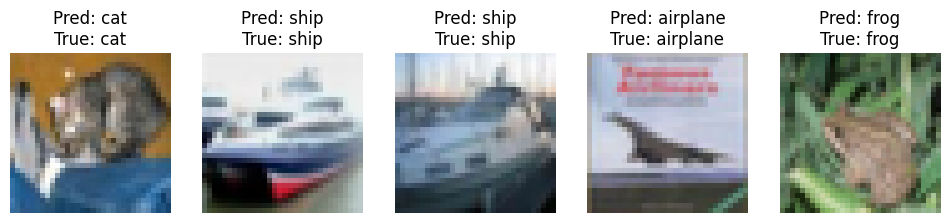

In [ ]:
import matplotlib.pyplot as plt

# --- 결과 시각화 ---
plt.figure(figsize=(12, 4))
for i, img in enumerate(sample_images):
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    # 이미지 제목에 예측 결과와 실제 정답 표시
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis('off')
plt.show()

### HuggingFace Pipeline 사용

HuggingFace의 [pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines)을 사용하면 위 과정을 더 간단하게 처리할 수도 있습니다.

이와 같이 하면 이미지마다 예측된 레이블과 신뢰도(score)를 쉽게 얻을 수 있습니다. pipeline은 내부적으로 image processor와 모델 예측 과정을 캡슐화하여 편의성을 제공합니다.

In [ ]:
from transformers import pipeline
# 이미지 분류 파이프라인 생성
clf = pipeline(task="image-classification", model=model_name, device=device)

preds = clf(sample_images)
print(preds)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use mps


[[{'label': 'LABEL_3', 'score': 0.9927236437797546}, {'label': 'LABEL_5', 'score': 0.0012952471151947975}, {'label': 'LABEL_9', 'score': 0.0009297917131334543}, {'label': 'LABEL_0', 'score': 0.0008214300614781678}, {'label': 'LABEL_8', 'score': 0.0007351305685006082}], [{'label': 'LABEL_8', 'score': 0.9955234527587891}, {'label': 'LABEL_1', 'score': 0.0007332793902605772}, {'label': 'LABEL_0', 'score': 0.000533053302206099}, {'label': 'LABEL_2', 'score': 0.0005047424929216504}, {'label': 'LABEL_4', 'score': 0.0005029552266933024}], [{'label': 'LABEL_8', 'score': 0.9930387139320374}, {'label': 'LABEL_1', 'score': 0.0024215076118707657}, {'label': 'LABEL_4', 'score': 0.0006866455078125}, {'label': 'LABEL_9', 'score': 0.0006693329778499901}, {'label': 'LABEL_3', 'score': 0.0006172179710119963}], [{'label': 'LABEL_0', 'score': 0.9931061863899231}, {'label': 'LABEL_2', 'score': 0.001925262506119907}, {'label': 'LABEL_3', 'score': 0.0007438045577146113}, {'label': 'LABEL_7', 'score': 0.00073

In [ ]:
# 예측 결과를 더 읽기 쉽게 출력
print("Pipeline 예측 결과:")
for i, pred_list in enumerate(preds):
    print(f"이미지 {i+1}:")
    for pred in pred_list:
        # 'LABEL_X' 문자열에서 레이블 인덱스 추출
        label_index = int(pred['label'].split('_')[1])
        print(f"  - 레이블: {labels[label_index]}, 신뢰도: {pred['score']:.4f}")

## 자가 체크리스트

아래 항목을 스스로 점검한다. 설명할 수 있으면 ✅, 불확실하면 해당 Step을 다시 복습한다.

### 개념 이해
- [ ] 전이학습이 왜 효과적인지 한 문장으로 설명할 수 있다
- [ ] Linear Probing과 Fine-tuning의 차이를 설명할 수 있다
- [ ] `requires_grad = False`가 어떤 효과를 내는지 설명할 수 있다
- [ ] 데이터 증강이 과적합을 방지하는 원리를 설명할 수 있다
- [ ] 학습률 스케줄러가 왜 필요한지 설명할 수 있다
- [ ] CNN과 ViT의 핵심 차이를 설명할 수 있다

### 코드 구현
- [ ] 사전 학습 모델의 분류층을 새 태스크에 맞게 교체할 수 있다
- [ ] 특정 층의 파라미터를 동결/해제할 수 있다
- [ ] 학습 루프 5단계를 구현할 수 있다
- [ ] HuggingFace에서 모델을 로드하고 추론을 수행할 수 있다

### 결과 해석
- [ ] Linear Probing vs Fine-tuning 성능 차이의 원인을 설명할 수 있다
- [ ] 데이터 증강 적용 전후의 성능 변화를 해석할 수 있다

### 심화 도전 (선택)
- [ ] ResNet-18 대신 ResNet-50을 사용하면 성능이 어떻게 달라지는지 실험해 본다
- [ ] `ColorJitter`, `RandomRotation` 등 추가 증강 기법을 적용해 본다
- [ ] StepLR 대신 `CosineAnnealingLR`을 사용하면 학습 추이가 어떻게 달라지는지 비교해 본다
- [ ] Fine-tuning 시 전체가 아닌 **마지막 몇 개 층만** 동결 해제하면 어떻게 되는지 실험해 본다


### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.